### 시각화 전략
 - 시각화 목표 1: 초등학교 학생의 1인당 교육비
 - 시각화 목표 2: 특성별 초등학생 사교육비 사용처
 - 시각화의 범위 : 초등학생 학생의 현황, 2012-2022년까지, 학교급별 사교육비 총액 2012-2022
 - 시각화의 개발절차 : kosis.kr 에서 데이터 확보, 분석 후 시각화

### 시각화 요구사항
- 사용자 수준/ 취향/ 목적 : 곧 초등학교 진학을 앞둔 부부. 앞으로 지출될 사교육비가 걱정된다.
- 시나리오 / 스토리보드 개발 : 평균적으로 초등학생은 얼마의 사교육비를 지출하는지 알고싶다.

### 데이터 시각화 명세서
- 시각화 표현의 형태, 규칙, 패턴, 상호작용 : lineplot,histplot을 사용하여 lineplot에는 년도별 1인당 초등학생당 사교육비의 증감그래프를 시각화하고, histplot에는 특성별로 초등학생은 어느 과목에 사교육비가 사용되었는지 시각화한다.

### 시각화 명세서 기반 설계
- 시각화 UI 설계: 년도별 lineplot을 seaborn으로 1인당_년_사교육비 시각화를 하고, histplot으로 초등학생 사교육비를 특성별로 시각화 하였다.

In [176]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib
import seaborn as sns

current_font_list = matplotlib.rcParams['font.family']

font_path = "C:\Windows\Fonts\HMKMRHD.TTF"
kfont = matplotlib.font_manager.FontProperties(fname=font_path).get_name()

matplotlib.rcParams['font.family'] = [kfont]+current_font_list

### 초등학생의 수를 정제
- '-' --> 결측치 '0'

In [177]:
element_students_data = pd.read_csv('초등학교_개황_2012-2022.csv',encoding='cp949', header=0)
# element_students_data.shape
# element_students_data['학생수 (명)'].astype(np.int64)
element_students_data['학생수 (명)'] = element_students_data['학생수 (명)'].replace('-','0').astype(np.int64)
# element_students_data.dtypes
element_students_data

,시도별(1),설립주체별(1),시점,학생수 (명)
0,총계,계,2012,2951995
1,총계,계,2013,2784000
2,총계,계,2014,2728509
3,총계,계,2015,2714610
4,총계,계,2016,2672843
...,...,...,...,...
783,제주,사립,2018,0
784,제주,사립,2019,0
785,제주,사립,2020,0
786,제주,사립,2021,0


### 학교급별 사교육비 총액 데이터
- 고등학교(억원)에 일반고(억원)의 비용이 포함되어 있는 비용이므로 제거

In [178]:
private_education_data = pd.read_csv('학교급별_사교육비_총액_2012-2022_서울_광역시별.csv',encoding='cp949')
# private_education_data.dtypes
private_education_data = private_education_data.drop(columns=['일반고 (억원)'], axis=1)
private_education_data

,특성별,시점,전체 (억원),초등학교 (억원),중학교 (억원),고등학교 (억원)
0,전체,2012,190395,77554,61162,51679
1,전체,2013,185960,77375,57831,50754
2,전체,2014,182297,75949,55678,50671
3,전체,2015,178346,75287,52384,50675
4,전체,2016,180606,77438,48102,55065
...,...,...,...,...,...,...
83,"유형: 예체능, 취미·교양 사교육",2018,50706,35039,5981,9686
84,"유형: 예체능, 취미·교양 사교육",2019,54274,38814,6210,9250
85,"유형: 예체능, 취미·교양 사교육",2020,38641,24685,5728,8228
86,"유형: 예체능, 취미·교양 사교육",2021,53102,38089,6603,8410


### 시각화 목표 1: 초등학교 학생의 1인당 교육비
### 시각화 목표 2: 특성별 초등학생 사교육비 사용처

In [179]:
print(element_students_data.shape)
print(private_education_data.shape)

(788, 4)
(88, 6)


In [181]:
# 전국의 초등학생의 수
filter1 = element_students_data['설립주체별(1)'] == '계'
filter2 = element_students_data['시도별(1)'] == '총계'
element_students_data_f = element_students_data[filter1]
element_students_data_f2 = element_students_data_f[filter2]
element_students_data_f2

C:\Users\ITPS\AppData\Local\Temp\ipykernel_13460\3883494395.py:5: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  element_students_data_f2 = element_students_data_f[filter2]


,시도별(1),설립주체별(1),시점,학생수 (명)
0,총계,계,2012,2951995
1,총계,계,2013,2784000
2,총계,계,2014,2728509
3,총계,계,2015,2714610
4,총계,계,2016,2672843
5,총계,계,2017,2674227
6,총계,계,2018,2711385
7,총계,계,2019,2747219
8,총계,계,2020,2693716
9,총계,계,2021,2672340


### 초등학생의 사교육비만을 보고 싶어서 나머지 데이터 제거

In [193]:
filter1 = private_education_data['특성별'] == '전체'
private_education_data_element = private_education_data[filter1]
private_education_data_element = private_education_data_element.drop(columns=['전체 (억원)','중학교 (억원)','고등학교 (억원)'])
private_education_data_element

,특성별,시점,초등학교 (억원)
0,전체,2012,77554
1,전체,2013,77375
2,전체,2014,75949
3,전체,2015,75287
4,전체,2016,77438
5,전체,2017,81311
6,전체,2018,85531
7,전체,2019,95597
8,전체,2020,76107
9,전체,2021,105279


In [195]:
frames1 = [element_students_data_f2.set_index(['시점']),private_education_data_element.set_index(['시점'])]

a = pd.concat(frames1, axis=1)
df1 = a.reset_index()
df1['1인당_년_초등교육비(천원)'] = ((df1['초등학교 (억원)'] * 100000) / df1['학생수 (명)'])
df1

,시점,시도별(1),설립주체별(1),학생수 (명),특성별,초등학교 (억원),1인당_년_초등교육비(천원)
0,2012,총계,계,2951995,전체,77554,2627.172471
1,2013,총계,계,2784000,전체,77375,2779.274425
2,2014,총계,계,2728509,전체,75949,2783.534890
3,2015,총계,계,2714610,전체,75287,2773.400231
4,2016,총계,계,2672843,전체,77438,2897.214689
5,2017,총계,계,2674227,전체,81311,3040.542183
6,2018,총계,계,2711385,전체,85531,3154.513284
7,2019,총계,계,2747219,전체,95597,3479.773546
8,2020,총계,계,2693716,전체,76107,2825.353527
9,2021,총계,계,2672340,전체,105279,3939.581041


In [190]:
filter1 = private_education_data['특성별'] != '전체'
private_education_data_element = private_education_data[filter1]
private_education_data_element = private_education_data_element.drop(columns=['전체 (억원)','중학교 (억원)','고등학교 (억원)'])
private_education_data_element

filter2 = []
for e in private_education_data['특성별']:
    if '과목' in e:
        filter2.append(True)
    else:
        filter2.append(False)

print(filter2)
test1= private_education_data[filter2]
test1

[False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, True, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False, False]


,특성별,시점,전체 (억원),초등학교 (억원),중학교 (억원),고등학교 (억원)
44,과목: 일반교과 사교육,2012,155773,54642,56571,44560
45,과목: 일반교과 사교육,2013,148802,52813,53016,42973
46,과목: 일반교과 사교육,2014,143831,49920,51122,42790
47,과목: 일반교과 사교육,2015,138947,47950,47678,43320
48,과목: 일반교과 사교육,2016,135056,45484,43053,46520
49,과목: 일반교과 사교육,2017,135865,46956,42317,46592
50,과목: 일반교과 사교육,2018,142600,50326,43864,48410
51,과목: 일반교과 사교육,2019,154052,56545,46191,51315
52,과목: 일반교과 사교육,2020,153223,51176,48070,53978
53,과목: 일반교과 사교육,2021,179398,66977,56719,55701


<AxesSubplot: xlabel='시점', ylabel='초등학교 (억원)'>

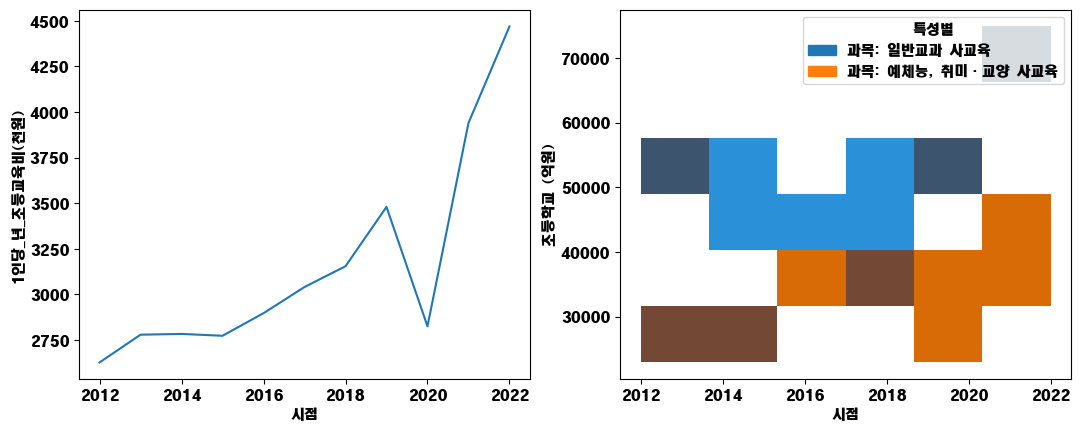

In [191]:
fig = plt.figure(figsize=(6.4*2,4.8*1))
x1 = fig.add_subplot(1,2,1)
x2 = fig.add_subplot(1,2,2)
sns.lineplot(data=df1,x='시점',y='1인당_년_초등교육비(천원)', ax=x1)
sns.histplot(data=test1, x='시점', y = '초등학교 (억원)', hue='특성별', ax=x2)

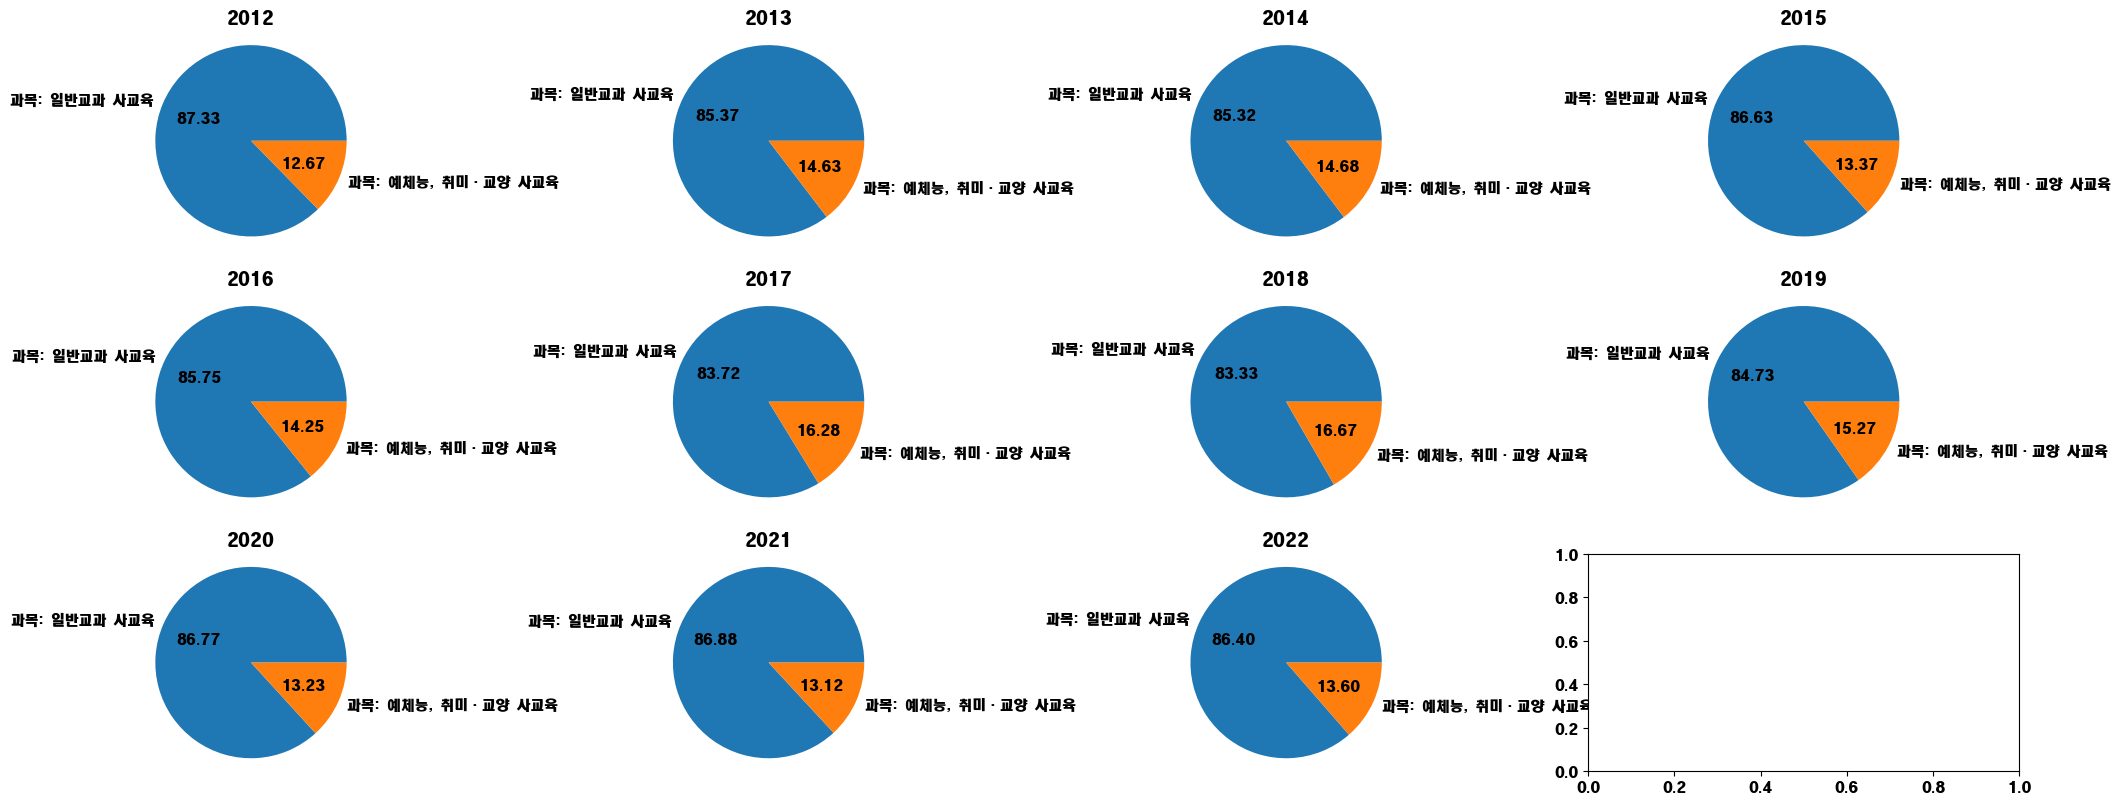

In [186]:

fig, axes = plt.subplots(3,4,figsize=(6.4*4, 4.8*2))
col_name = test1.columns
# print(col_name)

for i,e in enumerate(test1['시점'].unique()):
    filter1 = test1['시점'] == e
    ax = axes[i//4,i%4]
    xs = test1.loc[filter1,'시점']
    ys = test1.loc[filter1,col_name]
    ax.set_title(e)
    ax.pie(ys.iloc[:,-1], labels=ys.iloc[:,0],radius=1.1,autopct='%.2f')
